In [2]:
import xgboost as xgb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [2]:
df = pd.read_csv(r'D:\pypipeline\data\processed\us_paro_hourly_processed.csv',parse_dates=['date'], index_col='date')

In [3]:
df.index.max()

Timestamp('2021-03-13 00:00:00+0545', tz='UTC+05:45')

In [4]:
test = df["2017-03-03":"2021-03-07"]
test_train= df["2021-03-08":]

In [5]:
rf_model = xgb.XGBRegressor(max_depth=5,
                            n_estimators=100,seed=42,enable_categorical=True)

In [6]:
df.columns

Index(['pm25', 'o3', 'pm25_target', 'o3_target', 'hour', 'day_of_week',
       'is_weekend', 'is_night', 'pm25_missing', 'o3_missing',
       'pm25_gap_length', 'o3_gap_length', 'was_imputed',
       'imputation_confidence', 'hour_sin', 'hour_cos', 'segment_id',
       'pm25_lag_1', 'o3_lag_1', 'pm25_lag_2', 'o3_lag_2', 'pm25_lag_3',
       'o3_lag_3', 'pm25_lag_4', 'o3_lag_4', 'pm25_lag_5', 'o3_lag_5',
       'pm25_lag_6', 'o3_lag_6', 'pm25_lag_7', 'o3_lag_7', 'pm25_lag_8',
       'o3_lag_8', 'pm25_lag_9', 'o3_lag_9', 'pm25_lag_10', 'o3_lag_10',
       'pm25_lag_11', 'o3_lag_11', 'pm25_lag_12', 'o3_lag_12', 'pm25_lag_13',
       'o3_lag_13', 'pm25_lag_14', 'o3_lag_14', 'pm25_lag_15', 'o3_lag_15',
       'pm25_lag_16', 'o3_lag_16', 'pm25_lag_17', 'o3_lag_17', 'pm25_lag_18',
       'o3_lag_18', 'pm25_lag_19', 'o3_lag_19', 'pm25_lag_20', 'o3_lag_20',
       'pm25_lag_21', 'o3_lag_21', 'pm25_lag_22', 'o3_lag_22', 'pm25_lag_23',
       'o3_lag_23', 'pm25_lag_24', 'o3_lag_24', 'pm25_roll_3h

In [7]:
x = df.drop(["pm25","o3","o3_target","pm25_target","pm25_gap_length","o3_gap_length","o3_missing"],axis=1)
# convert object-like categorical column to pandas 'category' so XGBoost accepts it
if "imputation_confidence" in x.columns and x["imputation_confidence"].dtype == object:
	x["imputation_confidence"] = x["imputation_confidence"].astype("category")
y = df["pm25_target"]

# drop rows with missing or non-finite target values before fitting
mask = y.notna()
x = x.loc[mask]
y = y.loc[mask]

rf_model.fit(x, y)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [8]:
predictions = rf_model.predict(x)

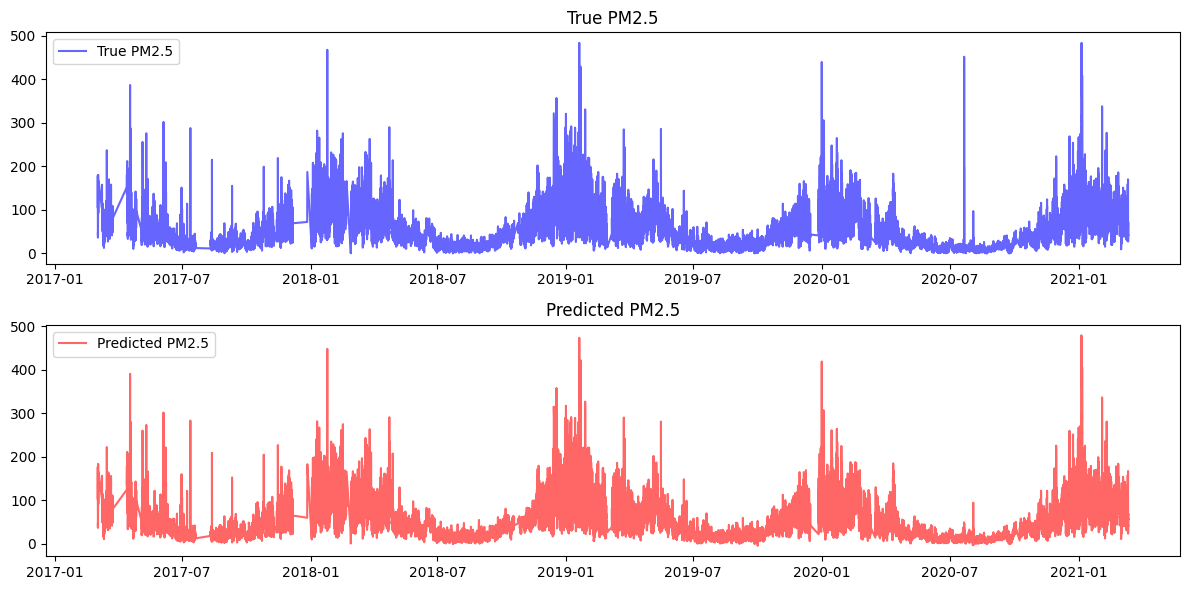

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

axes[0].plot(x.index, y, label='True PM2.5', color='blue', alpha=0.6)
axes[0].set_title('True PM2.5')
axes[0].legend()

axes[1].plot(x.index, predictions, label='Predicted PM2.5', color='red', alpha=0.6)
axes[1].set_title('Predicted PM2.5')
axes[1].legend()
plt.tight_layout()

In [10]:
train = df["2017-03-03":"2021-03-07"]
test= df["2021-03-08":]
x_train = train.drop(["pm25","o3","o3_target","pm25_target","pm25_gap_length","o3_gap_length","o3_missing"],axis=1)
y_train = train["pm25_target"]

x_test = test.drop(["pm25","o3","o3_target","pm25_target","pm25_gap_length","o3_gap_length","o3_missing"],axis=1)
y_test = test["pm25_target"]

if "imputation_confidence" in x_train.columns and x_train["imputation_confidence"].dtype == object:
    x_train["imputation_confidence"] = x_train["imputation_confidence"].astype("category")

if "imputation_confidence" in x_test.columns and x_test["imputation_confidence"].dtype == object:
    x_test["imputation_confidence"] = x_test["imputation_confidence"].astype("category")

mask_train = y_train.notna()
x_train = x_train.loc[mask_train]
y_train = y_train.loc[mask_train]    


In [11]:
xgb_model = xgb.XGBRegressor(max_depth=5,
                            n_estimators=100,seed=42,enable_categorical=True)

In [12]:
x_train.shape

(29239, 71)

In [13]:
xgb_model.fit(x_train, y_train)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


xgb_model.feature_importances_

In [14]:
pred = xgb_model.predict(x_test)
pred_dates = x_test.index

In [15]:
y_test.shift

<bound method NDFrame.shift of date
2021-03-08 00:00:00+05:45    76.0
2021-03-08 01:00:00+05:45    76.0
2021-03-08 02:00:00+05:45    87.0
2021-03-08 03:00:00+05:45    92.0
2021-03-08 04:00:00+05:45    87.0
                             ... 
2021-03-12 20:00:00+05:45    58.0
2021-03-12 21:00:00+05:45    58.0
2021-03-12 22:00:00+05:45    60.0
2021-03-12 23:00:00+05:45    69.0
2021-03-13 00:00:00+05:45    69.0
Name: pm25_target, Length: 121, dtype: float64>

In [16]:
from sklearn.metrics import mean_squared_error

# align shifted true values with predictions (drop the NaN introduced by the shift)
y_shift = y_test.shift(-1).loc[pred_dates]
y_true = y_shift.dropna()
pred_series = pd.Series(pred, index=pred_dates).loc[y_true.index]

rmse = np.sqrt(mean_squared_error(y_true, pred_series))
rmse

np.float64(16.482371949104078)

In [24]:
y_true

date
2021-03-08 00:00:00+05:45    76.0
2021-03-08 01:00:00+05:45    87.0
2021-03-08 02:00:00+05:45    92.0
2021-03-08 03:00:00+05:45    87.0
2021-03-08 04:00:00+05:45    87.0
                             ... 
2021-03-12 19:00:00+05:45    58.0
2021-03-12 20:00:00+05:45    58.0
2021-03-12 21:00:00+05:45    60.0
2021-03-12 22:00:00+05:45    69.0
2021-03-12 23:00:00+05:45    69.0
Name: pm25_target, Length: 117, dtype: float64

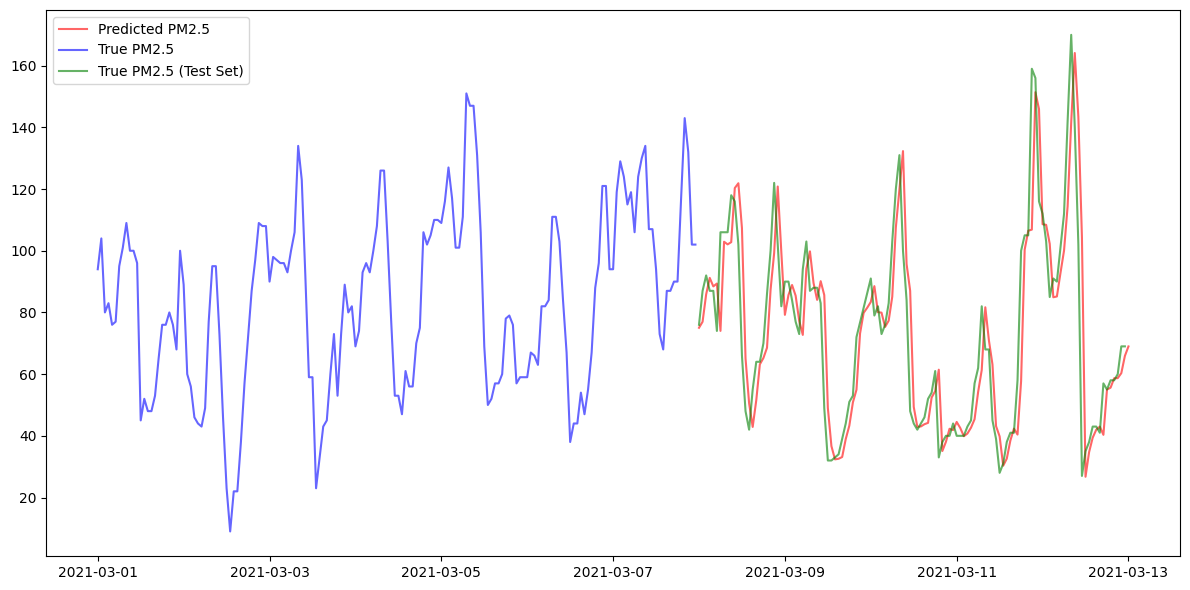

In [25]:
plt.figure(figsize=(12, 6))
plt.plot(x_test.index, pred, color='red', alpha=0.6, label='Predicted PM2.5')
plt.plot(x_train["2021-03-01":].index, y_train["2021-03-01":], color='blue', alpha=0.6, label='True PM2.5')
plt.plot(y_true.index, y_true, color='green', alpha=0.6, label='True PM2.5 (Test Set)')
plt.legend()
plt.tight_layout()



## forcasting with future features (t+1) and training with them 

#### Splitting data, for testing validaton
train = 70%, validation = 15%, test = 15%
the data is split based on time series order, not randomly

In [ ]:
forcasting = pd.read_csv(r'D:\pypipeline\data\processed\us_paro_hourly_processed.csv',parse_dates=['date'], index_col='date')


Splitting based on ratios using iloc to preserve time series order

In [ ]:
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

train_end = int(len(forcasting) * train_ratio)
val_end = int(len(forcasting) * (train_end + val_ratio))

df_train = forcasting.iloc[:train_end]
df_val = forcasting.iloc[train_end:val_end]
df_test = forcasting.iloc[val_end:]

In [ ]:
train_size

In [ ]:
test